In [1]:
#!pip install pandas
!pip install tensorflow

#!pip install matplotlib



Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# Parse dates and set date column to index
df = pd.read_csv("data/btc1h_usdt.csv", 
                 parse_dates=["open_time"], 
                 index_col=["open_time"]) # parse the date column (tell pandas column 1 is a datetime)
#Sorting the data based on Increasing value of date
df.sort_values(by='open_time',ascending=True, inplace = True)
df.head()
df.tail()

,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
open_time,,,,,,,,,,,,,,,,,,,,,
2025-01-09 13:00:00,64725,93421.94,93486.19,91900.12,92113.06,3356.62241,2025-01-09 13:59:59.999,3.103351e+08,348237.0,1256.86418,...,NaN,NaN,NaN,97273.08590,95605.9272,96902.623310,95507.199053,-102.948968,-615.768747,-0.838106
2025-01-09 14:00:00,64726,91986.41,92786.54,91800.00,92786.54,2300.48467,2025-01-09 14:59:59.999,2.123335e+08,373009.0,1108.75649,...,NaN,NaN,NaN,97268.32430,95446.9710,96861.667257,95400.506541,-105.304683,-585.623974,-0.422068
2025-01-09 15:00:00,64727,92863.81,94588.23,92671.67,94363.64,2478.34893,2025-01-09 15:59:59.999,2.320427e+08,350503.0,1350.80201,...,NaN,NaN,NaN,97271.72195,95321.2208,96836.811265,95359.845108,-102.499874,-338.764423,0.807167
2025-01-09 16:00:00,64728,94244.02,94685.25,93846.15,94230.62,1572.89161,2025-01-09 16:59:59.999,1.482196e+08,256347.0,666.46850,...,NaN,NaN,NaN,97275.66650,95206.1168,96810.879013,95315.561771,-95.932735,-179.430363,1.665067
2025-01-09 17:00:00,64729,94250.96,94293.96,92325.00,92795.16,1851.18100,2025-01-09 17:59:59.999,1.724752e+08,376721.0,780.35803,...,NaN,NaN,NaN,97272.63165,95101.7164,96770.921610,95216.722486,-91.207137,8.423442,1.456560


In [3]:
#Setting The training set ratio
training_ratio = 80

#Calculating the test set ratio
test_ratio = 100-training_ratio

#Rounding the training set length to avoid fractions
training_len = round(len(df)*(training_ratio/100))

#Setting the Test set length
test_len = round(len(df)-training_len)

#Splitting the data based on the calculated lengths
dataset_train = df.tail(training_len)
dataset_test = df.head(test_len)

#Printing the shapes of training and test sets

print("Shape Of Training Set :", dataset_train.shape)
print("Shape Of Test Set :", dataset_test.shape)

Shape Of Training Set : (51784, 111)
Shape Of Test Set : (12946, 111)


In [4]:
# Printing the training and test sets
print(dataset_test.tail(10))
print(dataset_train.head(10))

                     Unnamed: 0     open     high      low    close  \
open_time                                                             
2019-02-10 01:00:00       12936  3658.23  3663.00  3649.98  3655.84   
2019-02-10 02:00:00       12937  3655.26  3662.12  3653.06  3653.08   
2019-02-10 03:00:00       12938  3654.13  3657.65  3646.44  3654.84   
2019-02-10 04:00:00       12939  3654.80  3660.00  3651.16  3658.55   
2019-02-10 05:00:00       12940  3658.17  3659.46  3651.00  3654.90   
2019-02-10 06:00:00       12941  3653.12  3654.84  3630.98  3634.81   
2019-02-10 07:00:00       12942  3635.92  3641.03  3609.76  3632.12   
2019-02-10 08:00:00       12943  3632.10  3642.00  3631.03  3638.36   
2019-02-10 09:00:00       12944  3638.36  3639.10  3631.95  3636.98   
2019-02-10 10:00:00       12945  3636.66  3647.95  3636.46  3644.89   

                          volume               close_time     quote_vol  \
open_time                                                               

In [5]:
#Sorting the dataset based on increasing Dates
dataset_train.sort_values(by='open_time',ascending=True, inplace = True)

C:\Users\vasil\AppData\Local\Temp\ipykernel_6816\764546335.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_train.sort_values(by='open_time',ascending=True, inplace = True)


In [6]:
print(dataset_train.head(10))

                     Unnamed: 0     open     high      low    close  \
open_time                                                             
2019-02-10 11:00:00       12946  3644.77  3647.95  3630.78  3638.34   
2019-02-10 12:00:00       12947  3639.53  3642.78  3622.50  3626.17   
2019-02-10 13:00:00       12948  3625.94  3635.04  3616.00  3630.78   
2019-02-10 14:00:00       12949  3630.78  3637.00  3615.53  3619.50   
2019-02-10 15:00:00       12950  3619.50  3634.77  3618.46  3626.60   
2019-02-10 16:00:00       12951  3628.73  3655.00  3624.03  3647.05   
2019-02-10 17:00:00       12952  3647.12  3651.06  3631.94  3638.41   
2019-02-10 18:00:00       12953  3638.85  3650.00  3638.32  3646.32   
2019-02-10 19:00:00       12954  3646.32  3649.00  3637.55  3645.69   
2019-02-10 20:00:00       12955  3645.47  3645.71  3636.00  3639.73   

                          volume               close_time     quote_vol  \
open_time                                                               

In [7]:
#### Scaling and Sequencing #####
#A method to preprocess the data in to sequences and to return x and y 

#Initializing the MinMaxScaler object
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))

def bit_pre_process(raw_data , seq_len, column = 1):
  
  #Select the feature/column 
  data = raw_data.iloc[:, column].values
  data = data.reshape(-1, 1)
  
  #Feature Scaling
  data = sc.fit_transform(data)
  
  #Making sequences
  
  X = []
  y = []

  for i in range(seq_len, len(data)):
      X.append(data[i-seq_len:i, 0])
      y.append(data[i, 0])
  X, y = np.array(X), np.array(y)

  # Reshaping
  X = np.reshape(X, (X.shape[0], X.shape[1], 1))
  
  return X, y

In [8]:
#Setting the sequence length (Try different values)
sequence_length = 60

#Choosing the idex of the Close column
comumn_index= 3

#Preprocessing the training set
X_train, y_train = bit_pre_process(dataset_train , sequence_length, comumn_index)

In [9]:
X_train.shape

(51724, 60, 1)

In [10]:
y_train.shape

(51724,)

In [11]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Input

# Initializing the RNN
regressor = Sequential()

# Adding Input layer
regressor.add(Input(shape=(X_train.shape[1], 1)))

# Adding the first LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True, activation='relu'))
regressor.add(Dropout(0.2))

# Adding a second LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True, activation='relu'))
regressor.add(Dropout(0.2))

# Adding a third LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True, activation='relu'))
regressor.add(Dropout(0.2))

# Adding a fourth LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, activation='relu'))
regressor.add(Dropout(0.2))

# Adding the output layer
regressor.add(Dense(units=1))


In [12]:
#Compiling the RNN
regressor.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse', 'mae', 'mape', 'cosine_similarity'])

In [13]:
#Fitting the RNN to the Training set and training the RNN
regressor.fit(X_train, y_train, epochs = 50, batch_size = 50)

Epoch 1/50
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - cosine_similarity: 0.9947 - loss: 0.0081 - mae: 0.0478 - mape: 95.2531 - mse: 0.0081
Epoch 2/50
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 74s 71ms/step - cosine_similarity: 0.9808 - loss: 9.7847e-04 - mae: 0.0206 - mape: 256.2169 - mse: 9.7847e-04
Epoch 3/50
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - cosine_similarity: 0.9750 - loss: 7.5645e-04 - mae: 0.0188 - mape: 121.6647 - mse: 7.5645e-04
Epoch 4/50
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 76s 73ms/step - cosine_similarity: 0.9694 - loss: 6.7066e-04 - mae: 0.0181 - mape: 62.8051 - mse: 6.7066e-04
Epoch 5/50
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 75s 72ms/step - cosine_similarity: 0.9673 - loss: 6.7160e-04 - mae: 0.0183 - mape: 189.3451 - mse: 6.7160e-04
Epoch 6/50
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 74s 72ms/step - cosine_similarity: 0.9652 - loss: 6.7091e-04 - mae: 0.0184 - mape: 625.3450 - mse: 6.7091e-04
Epoch 7/50
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 74s 71ms/step - cosine_similarity: 0.9648 - loss: 6.4322

In [14]:
#Displaying the dataset
dataset_test.head()

,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
open_time,,,,,,,,,,,,,,,,,,,,,
2017-08-17 04:00:00,0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999,202366.138393,171.0,35.160503,...,NaN,NaN,NaN,NaN,NaN,4308.830000,4308.830000,NaN,NaN,NaN
2017-08-17 05:00:00,1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999,100304.823567,102.0,21.448071,...,NaN,NaN,NaN,NaN,NaN,4308.894577,4309.084510,NaN,NaN,NaN
2017-08-17 06:00:00,2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999,31282.312670,36.0,4.802861,...,NaN,NaN,NaN,NaN,NaN,4309.048362,4309.683156,NaN,NaN,NaN
2017-08-17 07:00:00,3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999,19241.058300,25.0,2.602292,...,NaN,NaN,NaN,NaN,NaN,4309.455742,4311.263817,NaN,NaN,NaN
2017-08-17 08:00:00,4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999,4239.503586,28.0,0.814655,...,NaN,NaN,NaN,NaN,NaN,4309.965536,4313.202099,NaN,NaN,NaN


In [15]:
#Adding the previous 60 days cosing price to the test data
test_set = pd.concat((dataset_train.tail(sequence_length), dataset_test), axis = 0)

In [16]:
test_set.shape

(13006, 111)

In [17]:
#Preprocessing the test data
x_test, y_true = bit_pre_process(test_set , sequence_length, comumn_index)

In [18]:
x_test.shape

(12946, 60, 1)

In [19]:
#Predicting the closing price of the test data
predicted_stock_price = regressor.predict(x_test)

405/405 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step


In [20]:
#Inversing the scaled values 
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

In [21]:
#Inversing the scaled actual prices from test data
real_stock_price = sc.inverse_transform(y_true.reshape(-1, 1))

In [22]:
# A Method to plot predicted pirce vs Actual price
def plot_predictions(real_price, predicted_price, title, x_label, y_label):
  plt.plot(real_price, color = 'green', label = 'Real Price')
  plt.plot(predicted_price, color = 'red', label = 'Predicted Price')
  plt.title(title)
  plt.xlabel('Time')
  plt.ylabel('Price')
  plt.legend()
  plt.show()

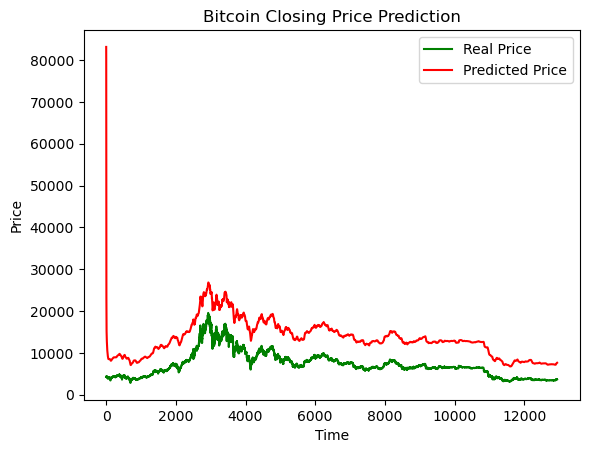

In [23]:
#Plotting real_stock_pric vs predicted_stock_pric
plot_predictions(real_stock_price, predicted_stock_price, "Bitcoin Closing Price Prediction", "Time", "Closing Price")

In [24]:
dataset_test['Predicted_Close'] = predicted_stock_price

C:\Users\vasil\AppData\Local\Temp\ipykernel_6816\1340485497.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_test['Predicted_Close'] = predicted_stock_price


In [25]:
compare = dataset_test[['open','close','Predicted_Close' ]]

In [26]:
compare.head(20)

,open,close,Predicted_Close
open_time,,,
2017-08-17 04:00:00,4261.48,4308.83,83149.710938
2017-08-17 05:00:00,4308.83,4315.32,80315.585938
2017-08-17 06:00:00,4330.29,4324.35,57874.351562
2017-08-17 07:00:00,4316.62,4349.99,44428.441406
2017-08-17 08:00:00,4333.32,4360.69,35099.960938
2017-08-17 09:00:00,4360.00,4444.00,28269.417969
2017-08-17 10:00:00,4441.10,4460.00,23197.972656
2017-08-17 11:00:00,4460.00,4427.30,19951.480469
2017-08-17 12:00:00,4436.06,4411.00,18014.937500


In [27]:
compare.tail(20)

,open,close,Predicted_Close
open_time,,,
2019-02-09 15:00:00,3660.45,3645.02,7479.037598
2019-02-09 16:00:00,3645.02,3646.22,7490.795898
2019-02-09 17:00:00,3645.95,3642.66,7501.363770
2019-02-09 18:00:00,3642.66,3640.37,7511.350586
2019-02-09 19:00:00,3640.06,3652.19,7521.416504
2019-02-09 20:00:00,3653.56,3656.62,7531.610840
2019-02-09 21:00:00,3657.42,3665.78,7541.809082
2019-02-09 22:00:00,3665.78,3660.37,7551.804688
2019-02-09 23:00:00,3660.83,3665.18,7561.399414


In [28]:
#A function to decide buy or sell (1 for sell and 0 for buy)

def buy_sell(op, cl):
  
  #If closing price is greater than the opening price, its a buy
  if cl > op:    
    return 1
  #If closing price is lesser than the opening price, its a sell 
  else:
    return 0
      

In [29]:
#Mapping the buy_sell method to the actual closing price in the test data and saving it as a column
compare["Buy-(Actual)"] = list(map(buy_sell, compare['open'], compare['close']))

C:\Users\vasil\AppData\Local\Temp\ipykernel_6816\1797123602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare["Buy-(Actual)"] = list(map(buy_sell, compare['open'], compare['close']))


In [30]:
#Mapping the buy_sell method to the predicted closing price in the test data and saving it as a column
compare["Buy-(Predicted)"] = list(map(buy_sell, compare['open'], compare['Predicted_Close']))

C:\Users\vasil\AppData\Local\Temp\ipykernel_6816\3448986927.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare["Buy-(Predicted)"] = list(map(buy_sell, compare['open'], compare['Predicted_Close']))


In [31]:
#Printing the new dataframe
compare.head(10)

,open,close,Predicted_Close,Buy-(Actual),Buy-(Predicted)
open_time,,,,,
2017-08-17 04:00:00,4261.48,4308.83,83149.710938,1,1
2017-08-17 05:00:00,4308.83,4315.32,80315.585938,1,1
2017-08-17 06:00:00,4330.29,4324.35,57874.351562,0,1
2017-08-17 07:00:00,4316.62,4349.99,44428.441406,1,1
2017-08-17 08:00:00,4333.32,4360.69,35099.960938,1,1
2017-08-17 09:00:00,4360.00,4444.00,28269.417969,1,1
2017-08-17 10:00:00,4441.10,4460.00,23197.972656,1,1
2017-08-17 11:00:00,4460.00,4427.30,19951.480469,0,1
2017-08-17 12:00:00,4436.06,4411.00,18014.937500,0,1


In [32]:
#Calculating Buy or Sell accuracy
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(compare['Buy-(Actual)'], compare['Buy-(Predicted)'])

In [33]:
Accuracy = cm.diagonal().sum()/cm.sum()
print("Buy or Sell Accuracy : ", Accuracy)

Buy or Sell Accuracy :  0.5122045419434574
